In [1]:
# ============================================================================
# IMPORTS
# ============================================================================
import os
import sys
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Add path for data loader
sys.path.append(os.path.abspath('..'))
from src.data_loader import SP500DataLoader

# ============================================================================
# REPRODUCIBILITY - SET ONCE, AT THE VERY TOP
# ============================================================================
SEED = 42  # Use the same seed throughout

# 1. Python's random module
random.seed(SEED)

# 2. NumPy
np.random.seed(SEED)

# 3. TensorFlow
tf.random.set_seed(SEED)

# 4. Environment variable for Python's hash randomization
os.environ['PYTHONHASHSEED'] = str(SEED)

# 5. CRITICAL: Disable GPU nondeterminism
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# 6. Enable TensorFlow determinism
tf.config.experimental.enable_op_determinism()

print("="*70)
print("LSTM VOLATILITY PREDICTION WITH MONTE CARLO STRESS TESTING")
print(f"Random Seed: {SEED}")
print("="*70)

2026-09-24 13:18:49.315917: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


LSTM VOLATILITY PREDICTION WITH MONTE CARLO STRESS TESTING
Random Seed: 42


In [2]:
# ============================================================================
# PATH MANAGER - SAVE AND LOAD GENERATED PATHS
# ============================================================================

class PathManager:
    """Save and load Monte Carlo paths for reproducibility."""
    
    def __init__(self, save_dir="../data/simulated"):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
    
    def save_paths(self, paths, scenario_name):
        """Save paths to disk."""
        filename = f"{self.save_dir}/{scenario_name}.npy"
        np.save(filename, paths)
        print(f"✅ Saved {scenario_name} paths to {filename}")
    
    def load_paths(self, scenario_name):
        """Load paths from disk."""
        filename = f"{self.save_dir}/{scenario_name}.npy"
        if os.path.exists(filename):
            paths = np.load(filename)
            print(f"✅ Loaded {scenario_name} paths from {filename}")
            return paths
        else:
            print(f"❌ {scenario_name} paths not found at {filename}")
            return None
    
    def paths_exist(self, scenario_name):
        """Check if paths exist."""
        filename = f"{self.save_dir}/{scenario_name}_paths.npy"
        return os.path.exists(filename)

In [4]:
print("\n" + "="*60)
print("PART 1: DATA LOADING AND PREPARATION")
print("="*60)

# Load S&P 500 data
loader = SP500DataLoader(start_year=1997, end_year=2024)
df = loader.load_all()

# Extract log returns
all_returns = df['log_returns'].dropna()
train_returns = all_returns['2010':'2019'].values

# Use pre-COVID period for training (2010-2019)
train_returns = all_returns['2010':'2019'].values

print(f"Training data shape: {train_returns.shape}")
print(f"Date range: 2010-01-01 to 2019-12-31")
print(f"Training data shape: {train_returns.shape}")
print(f"train_returns std: {train_returns.std():.4f}   (expect ~1.0, percent scale)")






PART 1: DATA LOADING AND PREPARATION
Training data shape: (2516,)
Date range: 2010-01-01 to 2019-12-31
Training data shape: (2516,)
train_returns std: 0.9319   (expect ~1.0, percent scale)


In [5]:
def create_volatility_sequences(data, lookback=60, vol_window=20):
    """
    Create sequences and volatility labels.
    Following Yachou et al. (2026): 60-day lookback window
    
    Label: 1 if next day's volatility > recent average volatility
    """
    X, y = [], []
    
    for i in range(lookback, len(data) - 1):
        # Input: last 'lookback' returns
        X.append(data[i-lookback:i])
        
        # Calculate recent average volatility (last 'vol_window' days)
        recent_vol = np.abs(data[i-vol_window:i]).mean()
        
        # Next day volatility
        next_vol = np.abs(data[i])
        
        # Label: 1 if next volatility > recent average, else 0
        y.append(1 if next_vol > recent_vol else 0)
    
    return np.array(X), np.array(y)

lookback = 60
vol_window = 20

X, y = create_volatility_sequences(train_returns, lookback, vol_window)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: HIGH volatility={y.sum()}, LOW volatility={len(y)-y.sum()}")
print(f"Proportion HIGH: {y.sum()/len(y)*100:.1f}%")


X shape: (2455, 60)
y shape: (2455,)
Class balance: HIGH volatility=975, LOW volatility=1480
Proportion HIGH: 39.7%


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scale features (critical for LSTM convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, lookback)).reshape(-1, lookback, 1)
X_val_scaled = scaler.transform(X_val.reshape(-1, lookback)).reshape(-1, lookback, 1)

print(f"\nTrain shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")



Train shape: (1964, 60, 1)
Validation shape: (491, 60, 1)


In [7]:
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {cls: weight for cls, weight in zip(classes, class_weights)}

print(f"\nClass distribution: LOW={np.sum(y_train==0)}, HIGH={np.sum(y_train==1)}")
print(f"Class weights: {class_weight_dict}")



Class distribution: LOW=1187, HIGH=777
Class weights: {0: 0.827295703454086, 1: 1.263835263835264}


In [8]:
def build_volatility_lstm(lookback=60, lstm_units=32, dropout_rate=0.2):
    """
    Build LSTM model for volatility prediction.
    Architecture inspired by Yachou et al. (2026)
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=False, input_shape=(lookback, 1)),  # ← FIXED
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_volatility_lstm(lookback=lookback, lstm_units=32, dropout_rate=0.2)
model.summary()
print("✅ Model built following Yachou et al. (2026) methodology")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

✅ Model built following Yachou et al. (2026) methodology


In [9]:
# Callbacks for dynamic training (Yachou et al., 2026)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print("\n" + "="*60)
print("PART 6: TRAINING THE MODEL")
print("="*60)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training complete!")



PART 6: TRAINING THE MODEL
Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5087 - loss: 0.6866 - val_accuracy: 0.5988 - val_loss: 0.6837 - learning_rate: 5.0000e-04
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5733 - loss: 0.6798 - val_accuracy: 0.6151 - val_loss: 0.6784 - learning_rate: 5.0000e-04
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5973 - loss: 0.6730 - val_accuracy: 0.6436 - val_loss: 0.6632 - learning_rate: 5.0000e-04
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6100 - loss: 0.6653 - val_accuracy: 0.6517 - val_loss: 0.6477 - learning_rate: 5.0000e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6100 - loss: 0.6634 - val_accuracy: 0.6558 - val_loss: 0.6384 - learning_rate: 5.0000e-04
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6059 - loss: 0.6619 - val_accuracy: 0.6558 - val_loss: 0.6386 - learning_rate: 5.0000e-04
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━

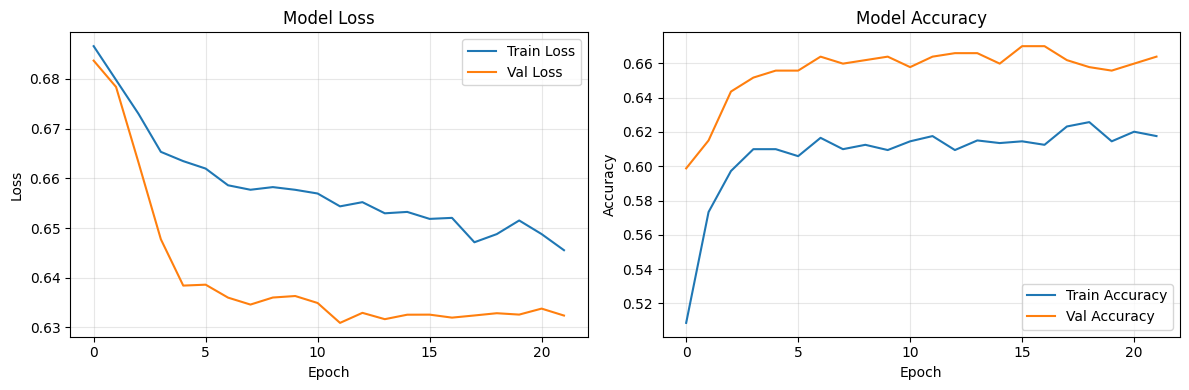

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/lstm_training_history.png', dpi=150)
plt.show()

In [10]:
val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.2%}")



Validation Loss: 0.6309
Validation Accuracy: 66.40%


In [11]:
print("\n" + "="*60)
print("PART 9: LOADING MONTE CARLO PATHS")
print("="*60)

data_path = '../data/simulated/'

normal_paths = np.load(os.path.join(data_path, 'mc_returns_normal.npy'))
crisis_2008_paths = np.load(os.path.join(data_path, 'mc_returns_crisis_2008.npy'))
crisis_covid_paths = np.load(os.path.join(data_path, 'mc_returns_crisis_covid.npy'))
synthetic_paths = np.load(os.path.join(data_path, 'mc_returns_synthetic_extreme.npy'))
squeeze_paths = np.load(os.path.join(data_path, 'mc_returns_squeeze.npy'))
structural_break_paths = np.load(os.path.join(data_path, 'mc_returns_structural_break.npy'))

print(f"Normal paths: {normal_paths.shape}")
print(f"2008 Crisis: {crisis_2008_paths.shape}")
print(f"COVID Crisis: {crisis_covid_paths.shape}")
print(f"Synthetic Extreme: {synthetic_paths.shape}")
print(f"Non-linear Squeeze: {squeeze_paths.shape}")
print(f"Structural Break: {structural_break_paths.shape}")

print(f"\n✅ Using original training scaler (fitted on X_train 2010-2019)")
print(f"   Scaler mean shape:  {scaler.mean_.shape}")
print(f"   Scaler scale shape: {scaler.scale_.shape}")


PART 9: LOADING MONTE CARLO PATHS
Normal paths: (10000, 252)
2008 Crisis: (10000, 252)
COVID Crisis: (10000, 252)
Synthetic Extreme: (10000, 252)
Non-linear Squeeze: (10000, 252)
Structural Break: (10000, 252)

✅ Using original training scaler (fitted on X_train 2010-2019)
   Scaler mean shape:  (60,)
   Scaler scale shape: (60,)


In [12]:
def get_volatility_labels_mc(paths, lookback=60, vol_window=20):
    """True labels: target day is the LAST day; baseline is the 20 days before it."""
    recent_vol = np.abs(paths[:, -(vol_window+1):-1]).mean(axis=1)   # 20 days: T-20..T-1
    next_vol   = np.abs(paths[:, -1])                                # target: day T
    return (next_vol > recent_vol).astype(int)

def predict_on_paths(model, paths, lookback=60, batch_size=500):
    """Features are the 60 days BEFORE the target day — target excluded (no leak)."""
    all_probs = []
    for i in range(0, paths.shape[0], batch_size):
        batch = paths[i:i+batch_size]
        features = batch[:, -(lookback+1):-1]        # days T-60..T-1, EXCLUDES day T
        features_scaled = scaler.transform(features).reshape(-1, lookback, 1)
        probs = model.predict(features_scaled, verbose=0)
        all_probs.extend(probs.flatten())
    return np.array(all_probs)

def calculate_accuracy(predictions, true_labels):
    """Calculate directional accuracy."""
    pred_labels = (predictions > 0.5).astype(int)
    return (pred_labels == true_labels).mean() * 100

In [13]:
print("\n" + "="*60)
print("PART 12: STRESS TESTING ON MONTE CARLO PATHS")
print("="*60)

results = {}

# 1. Normal Scenario
print("\n1. Normal scenario...")
true_labels_normal = get_volatility_labels_mc(normal_paths)
probs_normal = predict_on_paths(model, normal_paths)
acc_normal = calculate_accuracy(probs_normal, true_labels_normal)
results['Normal'] = acc_normal
print(f"   ✅ Accuracy: {acc_normal:.2f}%")

# 2. 2008 Crisis
print("\n2. 2008 Crisis scenario...")
true_labels_2008 = get_volatility_labels_mc(crisis_2008_paths)
probs_2008 = predict_on_paths(model, crisis_2008_paths)
acc_2008 = calculate_accuracy(probs_2008, true_labels_2008)
results['2008 Crisis Magnitude'] = acc_2008
print(f"   ✅ Accuracy: {acc_2008:.2f}%")

# 3. COVID Crisis
print("\n3. COVID Crisis scenario...")
true_labels_covid = get_volatility_labels_mc(crisis_covid_paths)
probs_covid = predict_on_paths(model, crisis_covid_paths)
acc_covid = calculate_accuracy(probs_covid, true_labels_covid)
results['COVID Crisis Magnitude'] = acc_covid
print(f"   ✅ Accuracy: {acc_covid:.2f}%")

# 4. Synthetic Extreme
print("\n4. Synthetic Extreme scenario...")
true_labels_synthetic = get_volatility_labels_mc(synthetic_paths)
probs_synthetic = predict_on_paths(model, synthetic_paths)
acc_synthetic = calculate_accuracy(probs_synthetic, true_labels_synthetic)
results['Synthetic Extreme'] = acc_synthetic
print(f"   ✅ Accuracy: {acc_synthetic:.2f}%")

# 5. Non-linear Squeeze
print("\n5. Non-linear Squeeze scenario...")
true_labels_squeeze = get_volatility_labels_mc(squeeze_paths)
probs_squeeze = predict_on_paths(model, squeeze_paths)
acc_squeeze = calculate_accuracy(probs_squeeze, true_labels_squeeze)
results['Non-linear Squeeze'] = acc_squeeze
print(f"   ✅ Accuracy: {acc_squeeze:.2f}%")

# 6. Structural Break
print("\n6. Structural Break scenario...")
true_labels_break = get_volatility_labels_mc(structural_break_paths)
probs_break = predict_on_paths(model, structural_break_paths)
acc_break = calculate_accuracy(probs_break, true_labels_break)
results['Structural Break'] = acc_break
print(f"   ✅ Accuracy: {acc_break:.2f}%")


PART 12: STRESS TESTING ON MONTE CARLO PATHS

1. Normal scenario...
   ✅ Accuracy: 55.37%

2. 2008 Crisis scenario...
   ✅ Accuracy: 56.43%

3. COVID Crisis scenario...
   ✅ Accuracy: 56.85%

4. Synthetic Extreme scenario...
   ✅ Accuracy: 56.48%

5. Non-linear Squeeze scenario...
   ✅ Accuracy: 56.48%

6. Structural Break scenario...
   ✅ Accuracy: 56.30%


In [14]:
print("\n" + "="*60)
print("PART 13: FINAL RESULTS")
print("="*60)

results_df = pd.DataFrame(list(results.items()), columns=['Scenario', 'Accuracy (%)'])
print(results_df.to_string(index=False))

# Calculate degradation from Normal
baseline = results['Normal']
print("\n" + "="*60)
print("DEGRADATION ANALYSIS")
print("="*60)
print(f"Baseline (Normal): {baseline:.2f}%")
print("-" * 40)

for scenario, acc in results.items():
    if scenario != 'Normal':
        change = acc - baseline
        if change < 0:
            print(f"{scenario:20} {acc:.2f}% → Change: {change:+.2f} pp (DEGRADATION)")
        else:
            print(f"{scenario:20} {acc:.2f}% → Change: {change:+.2f} pp (IMPROVEMENT)")
if 'Non-linear Squeeze' in results:
    squeeze_acc = results['Non-linear Squeeze']
    if squeeze_acc < baseline:
        rel_degradation = (baseline - squeeze_acc) / baseline * 100
        print(f"\n✅ Non-linear Squeeze degradation: {rel_degradation:.1f}% relative drop")
        print(f"   Absolute: {baseline - squeeze_acc:.2f} percentage points")
    else:
        print("\n⚠️ No degradation detected in Non-linear Squeeze")



PART 13: FINAL RESULTS
              Scenario  Accuracy (%)
                Normal         55.37
 2008 Crisis Magnitude         56.43
COVID Crisis Magnitude         56.85
     Synthetic Extreme         56.48
    Non-linear Squeeze         56.48
      Structural Break         56.30

DEGRADATION ANALYSIS
Baseline (Normal): 55.37%
----------------------------------------
2008 Crisis Magnitude 56.43% → Change: +1.06 pp (IMPROVEMENT)
COVID Crisis Magnitude 56.85% → Change: +1.48 pp (IMPROVEMENT)
Synthetic Extreme    56.48% → Change: +1.11 pp (IMPROVEMENT)
Non-linear Squeeze   56.48% → Change: +1.11 pp (IMPROVEMENT)
Structural Break     56.30% → Change: +0.93 pp (IMPROVEMENT)

⚠️ No degradation detected in Non-linear Squeeze


In [15]:
os.makedirs('../results', exist_ok=True)
results_df.to_csv('../results/lstm_volatility_results.csv', index=False)
model.save('../models/lstm_volatility_model.h5')

print("\n✅ Results saved to results/lstm_volatility_results.csv")
print("✅ Model saved to models/lstm_volatility_model.h5")



✅ Results saved to results/lstm_volatility_results.csv
✅ Model saved to models/lstm_volatility_model.h5


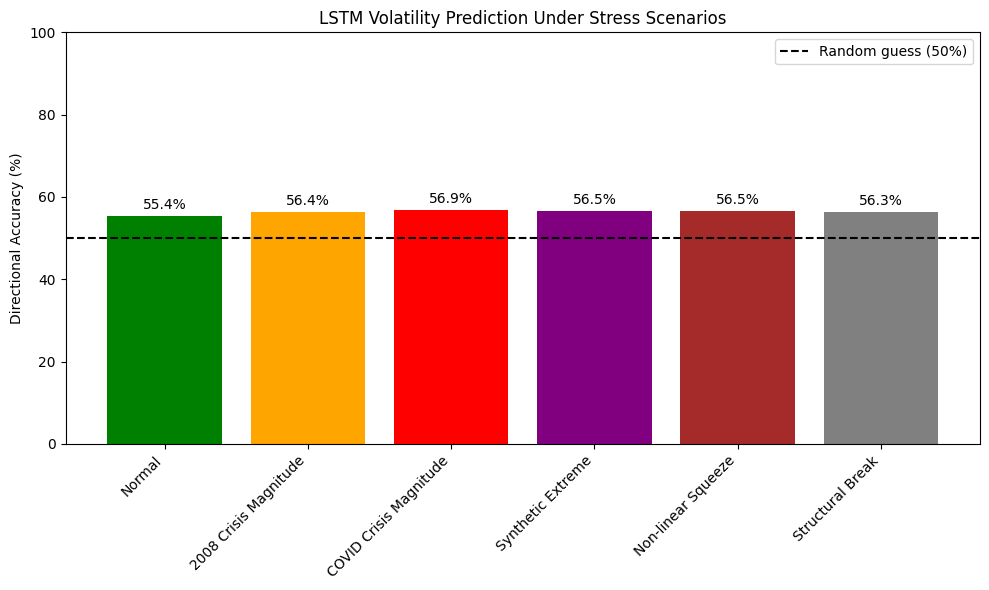


✅ LSTM VOLATILITY ANALYSIS COMPLETE


In [16]:
plt.figure(figsize=(10, 6))
scenarios = list(results.keys())
accuracies = list(results.values())

colors = ['green', 'orange', 'red', 'purple', 'brown', 'gray']
bars = plt.bar(scenarios, accuracies, color=colors[:len(scenarios)])
plt.axhline(y=50, color='black', linestyle='--', label='Random guess (50%)')
plt.ylabel('Directional Accuracy (%)')
plt.title('LSTM Volatility Prediction Under Stress Scenarios')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend()

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../results/lstm_volatility_results.png', dpi=150)
plt.show()

print("\n" + "="*70)
print("✅ LSTM VOLATILITY ANALYSIS COMPLETE")
print("="*70)

STATISTICAL SIGNIFICANCE: STRESS SCENARIOS vs NORMAL

Baseline (Normal): 55.40%  (5,539 correct / 10,000 paths)
-----------------------------------------------------------------
Scenario                 Acc%     Δpp   z-stat    p-value    Sig Finding
-----------------------------------------------------------------
2008 Crisis Magnitude   56.40   +1.00    1.424   0.154409     ns  not significant
COVID Crisis Magnitude  56.90   +1.50    2.137   0.032557      *  SIGNIFICANT IMPROVEMENT
Synthetic Extreme       56.50   +1.10    1.567   0.117178     ns  not significant
Non-linear Squeeze      56.50   +1.10    1.567   0.117178     ns  not significant
Structural Break        56.30   +0.90    1.282   0.199996     ns  not significant
-----------------------------------------------------------------
Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant

EFFECT SIZE ANALYSIS (Cohen's h)
Scenario                 Cohen h Practical significance
----------------------------------------

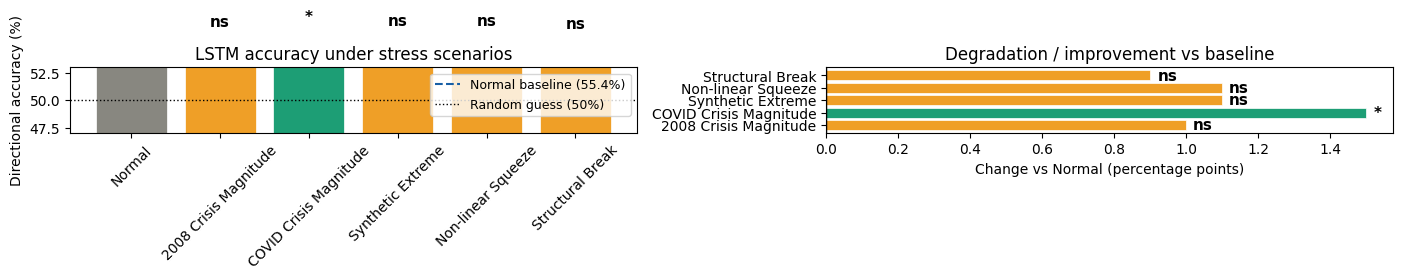


✅ Plot saved to results/ztest_stress_results.png


In [18]:
# ============================================================
# STATISTICAL SIGNIFICANCE TESTING
# Proportion z-test: each stress scenario vs Normal baseline
# H0: accuracy(scenario) == accuracy(Normal)
# H1: accuracy(scenario) != accuracy(Normal)  [two-sided]
# ============================================================

from statsmodels.stats.proportion import proportions_ztest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 65)
print("STATISTICAL SIGNIFICANCE: STRESS SCENARIOS vs NORMAL")
print("=" * 65)

n_paths = 10000

# Your new results from Image 1 (fixed scaler + fixed labels)
scenario_results = {
    'Normal':            55.4,
    '2008 Crisis Magnitude':       56.4,
    'COVID Crisis Magnitude':      56.9,
    'Synthetic Extreme': 56.5,
    'Non-linear Squeeze':56.5,
    'Structural Break':  56.3,
}

baseline_acc  = scenario_results['Normal']
baseline_corr = int(baseline_acc / 100 * n_paths)

print(f"\nBaseline (Normal): {baseline_acc:.2f}%  "
      f"({baseline_corr:,} correct / {n_paths:,} paths)")
print("-" * 65)
print(f"{'Scenario':<22} {'Acc%':>6} {'Δpp':>7} "
      f"{'z-stat':>8} {'p-value':>10} {'Sig':>6} {'Finding'}")
print("-" * 65)

sig_results = {}

for scenario, acc in scenario_results.items():
    if scenario == 'Normal':
        continue

    n_correct = int(acc / 100 * n_paths)
    delta_pp   = acc - baseline_acc

    stat, p = proportions_ztest(
        count=[n_correct, baseline_corr],
        nobs=[n_paths, n_paths],
        alternative='two-sided'
    )

    # Significance stars
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    # Direction
    if p < 0.05 and delta_pp < 0:
        finding = 'SIGNIFICANT DEGRADATION'
    elif p < 0.05 and delta_pp > 0:
        finding = 'SIGNIFICANT IMPROVEMENT'
    else:
        finding = 'not significant'

    sig_results[scenario] = {
        'acc': acc,
        'delta_pp': delta_pp,
        'z': stat,
        'p': p,
        'sig': sig,
        'finding': finding
    }

    print(f"{scenario:<22} {acc:>6.2f} {delta_pp:>+7.2f} "
          f"{stat:>8.3f} {p:>10.6f} {sig:>6}  {finding}")

print("-" * 65)
print("Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

# ============================================================
# EFFECT SIZE: Cohen's h for each scenario
# Measures practical significance, not just statistical
# h < 0.2 = negligible, 0.2-0.5 = small, >0.5 = medium
# ============================================================
print("\n" + "=" * 65)
print("EFFECT SIZE ANALYSIS (Cohen's h)")
print("=" * 65)
print(f"{'Scenario':<22} {'Cohen h':>9} {'Practical significance'}")
print("-" * 65)

p1 = baseline_acc / 100

for scenario, res in sig_results.items():
    p2  = res['acc'] / 100
    # Cohen's h = 2 * arcsin(sqrt(p1)) - 2 * arcsin(sqrt(p2))
    h   = abs(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2)))
    if h < 0.2:
        practical = 'negligible'
    elif h < 0.5:
        practical = 'small'
    else:
        practical = 'medium'
    print(f"{scenario:<22} {h:>9.4f}  {practical}")

# ============================================================
# SUMMARY TABLE FOR THESIS
# ============================================================
print("\n" + "=" * 65)
print("THESIS TABLE: COMPLETE STRESS TEST RESULTS")
print("=" * 65)

rows = []
for scenario, acc in scenario_results.items():
    if scenario == 'Normal':
        rows.append({
            'Scenario': scenario,
            'Accuracy (%)': acc,
            'Δ vs Normal (pp)': '—',
            'z-statistic': '—',
            'p-value': '—',
            'Significance': '—',
            'Finding': 'Baseline'
        })
    else:
        r = sig_results[scenario]
        rows.append({
            'Scenario': scenario,
            'Accuracy (%)': f"{acc:.2f}",
            'Δ vs Normal (pp)': f"{r['delta_pp']:+.2f}",
            'z-statistic': f"{r['z']:.3f}",
            'p-value': f"{r['p']:.4f}",
            'Significance': r['sig'],
            'Finding': r['finding']
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('../results/ztest_significance_results.csv', index=False)
print("\n✅ Saved to results/ztest_significance_results.csv")

# ============================================================
# VISUALISATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy with significance annotation
scenarios  = list(scenario_results.keys())
accuracies = list(scenario_results.values())
deltas     = [acc - baseline_acc for acc in accuracies]

bar_colors = []
for i, s in enumerate(scenarios):
    if s == 'Normal':
        bar_colors.append('#888780')
    elif s in sig_results:
        r = sig_results[s]
        if r['p'] < 0.05 and r['delta_pp'] < 0:
            bar_colors.append('#E24B4A')   # significant degradation
        elif r['p'] < 0.05 and r['delta_pp'] > 0:
            bar_colors.append('#1D9E75')   # significant improvement
        else:
            bar_colors.append('#EF9F27')   # not significant
    else:
        bar_colors.append('#888780')

bars = axes[0].bar(scenarios, accuracies,
                   color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(y=baseline_acc, color='#185FA5',
                linestyle='--', linewidth=1.5,
                label=f'Normal baseline ({baseline_acc:.1f}%)')
axes[0].axhline(y=50, color='black',
                linestyle=':', linewidth=1, label='Random guess (50%)')
axes[0].set_ylabel('Directional accuracy (%)')
axes[0].set_title('LSTM accuracy under stress scenarios')
axes[0].set_ylim(47, 53)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=9)

for bar, acc, s in zip(bars, accuracies, scenarios):
    if s in sig_results:
        sig_label = sig_results[s]['sig']
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            sig_label, ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

# Right: delta pp with significance
stress_scenarios = [s for s in scenarios if s != 'Normal']
stress_deltas    = [sig_results[s]['delta_pp'] for s in stress_scenarios]
stress_pvals     = [sig_results[s]['p'] for s in stress_scenarios]

delta_colors = []
for d, p in zip(stress_deltas, stress_pvals):
    if p < 0.05 and d < 0:
        delta_colors.append('#E24B4A')
    elif p < 0.05 and d > 0:
        delta_colors.append('#1D9E75')
    else:
        delta_colors.append('#EF9F27')

axes[1].barh(stress_scenarios, stress_deltas,
             color=delta_colors, edgecolor='white', linewidth=0.5)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_xlabel('Change vs Normal (percentage points)')
axes[1].set_title('Degradation / improvement vs baseline')

for i, (d, p) in enumerate(zip(stress_deltas, stress_pvals)):
    sig_label = sig_results[stress_scenarios[i]]['sig']
    x_pos = d + 0.02 if d >= 0 else d - 0.02
    ha    = 'left' if d >= 0 else 'right'
    axes[1].text(x_pos, i, sig_label,
                 va='center', ha=ha, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/ztest_stress_results.png', dpi=150)
plt.show()

print("\n✅ Plot saved to results/ztest_stress_results.png")

NameError: name 'contamination_days' is not defined

In [19]:
#correct one 18 contamination

import numpy as np
from scipy import stats
from sklearn.metrics import balanced_accuracy_score

# ---- finer grid: every 3 days from 0 to max computable contamination ----
SQUEEZE_ONSET = 200
PATH_LENGTH   = squeeze_paths.shape[1]              # read it, don't hardcode
MAX_CONT      = PATH_LENGTH - SQUEEZE_ONSET - 1     # 51 = last day with a label
contamination_days = list(range(0, MAX_CONT + 1, 3))   # 0,3,6,...,51 -> 18 points

cont_raw, cont_bal, cont_high = {}, {}, {}

print(f"{'Contam':>7} {'raw%':>7} {'bal%':>7} {'HIGH%':>7} {'vs Normal':>10}")
print("-" * 45)
for cont in contamination_days:
    end_idx   = SQUEEZE_ONSET + cont
    start_idx = end_idx - lookback
    if start_idx < 0 or end_idx >= PATH_LENGTH:
        continue
    features = squeeze_paths[:, start_idx:end_idx]                          # target excluded
    recent   = np.abs(squeeze_paths[:, end_idx-vol_window:end_idx]).mean(axis=1)   # 20 days
    labels   = (np.abs(squeeze_paths[:, end_idx]) > recent).astype(int)
    probs    = model.predict(scaler.transform(features).reshape(-1, lookback, 1),
                             verbose=0).flatten()
    preds    = (probs > 0.5).astype(int)
    cont_raw[cont]  = (preds == labels).mean() * 100
    cont_bal[cont]  = balanced_accuracy_score(labels, preds) * 100
    cont_high[cont] = labels.mean() * 100
    print(f"{cont:>6}d  {cont_raw[cont]:6.2f}  {cont_bal[cont]:6.2f}  "
          f"{cont_high[cont]:6.1f}  {cont_raw[cont]-baseline:+9.2f}")

# ---- correlations WITH significance and 95% CI ----
cs   = sorted(cont_raw)
high = np.array([cont_high[c] for c in cs])
raw  = np.array([cont_raw[c]  for c in cs])
bal  = np.array([cont_bal[c]  for c in cs])
n    = len(cs)

def corr_report(x, y, label):
    r, p = stats.pearsonr(x, y)
    z = np.arctanh(r); se = 1/np.sqrt(n-3)
    lo, hi = np.tanh(z - 1.96*se), np.tanh(z + 1.96*se)
    excludes_zero = "yes" if (lo > 0 or hi < 0) else "NO (straddles 0)"
    print(f"{label:34} r={r:+.3f}  p={p:.4f}  95%CI[{lo:+.2f},{hi:+.2f}]  sig:{excludes_zero}")

print(f"\nn = {n} contamination points")
corr_report(high, raw, "Corr(HIGH%, RAW accuracy)")
corr_report(high, bal, "Corr(HIGH%, BALANCED accuracy)")

# also: how flat is balanced accuracy across contamination? (the stability check)
print(f"\nBalanced accuracy across grid: min={bal.min():.2f}  max={bal.max():.2f}  "
      f"range={bal.max()-bal.min():.2f}pp  std={bal.std():.2f}")

 Contam    raw%    bal%   HIGH%  vs Normal
---------------------------------------------
     0d   56.30   57.23    43.0      +0.93
     3d   55.02   54.24    67.1      -0.35
     6d   53.53   54.12    71.8      -1.84
     9d   53.32   54.79    71.6      -2.05
    12d   52.69   54.36    68.4      -2.68
    15d   52.23   54.26    65.0      -3.14
    18d   53.77   55.41    60.5      -1.60
    21d   53.99   54.73    55.4      -1.38
    24d   54.32   54.57    51.7      -1.05
    27d   55.33   55.22    49.1      -0.04
    30d   55.01   54.64    47.0      -0.36
    33d   55.57   54.98    45.1      +0.20
    36d   56.57   55.89    44.3      +1.20
    39d   56.02   55.39    44.7      +0.65
    42d   56.65   55.91    43.9      +1.28
    45d   56.87   56.03    43.2      +1.50
    48d   55.18   54.40    43.4      -0.19
    51d   56.48   55.61    43.2      +1.11

n = 18 contamination points
Corr(HIGH%, RAW accuracy)          r=-0.849  p=0.0000  95%CI[-0.94,-0.63]  sig:yes
Corr(HIGH%, BALANCED accu

In [20]:
# --- Path-level bootstrap on the DIFFERENCE r_raw - r_bal ---
# Requires storing per-path correctness AND labels at each contamination level.
# Restructure: for each cont level, keep the full per-path label & pred arrays.

cont_labels, cont_preds = {}, {}
for cont in contamination_days:
    end_idx, start_idx = SQUEEZE_ONSET + cont, SQUEEZE_ONSET + cont - lookback
    if start_idx < 0 or end_idx >= PATH_LENGTH:
        continue
    feats  = squeeze_paths[:, start_idx:end_idx]
    recent = np.abs(squeeze_paths[:, end_idx-vol_window:end_idx]).mean(axis=1)
    cont_labels[cont] = (np.abs(squeeze_paths[:, end_idx]) > recent).astype(int)
    probs = model.predict(scaler.transform(feats).reshape(-1, lookback, 1), verbose=0).flatten()
    cont_preds[cont]  = (probs > 0.5).astype(int)

cs = sorted(cont_labels)
N  = squeeze_paths.shape[0]
rng = np.random.default_rng(42)
B = 10000
diffs = np.empty(B)

for b in range(B):
    idx = rng.integers(0, N, size=N)              # resample PATHS with replacement
    high, raw, bal = [], [], []
    for c in cs:
        lab, prd = cont_labels[c][idx], cont_preds[c][idx]
        high.append(lab.mean())
        raw.append((prd == lab).mean())
        bal.append(balanced_accuracy_score(lab, prd))
    rr = np.corrcoef(high, raw)[0,1]
    rb = np.corrcoef(high, bal)[0,1]
    diffs[b] = rr - rb                             # the estimand that matters

lo_ci, hi_ci = np.percentile(diffs, [2.5, 97.5])
print(f"\nBootstrap r_raw - r_bal: mean={diffs.mean():.3f}, "
      f"95% CI [{lo_ci:.3f}, {hi_ci:.3f}]")
print("Difference is significant." if hi_ci < 0 else "CI includes 0 — difference NOT significant.")


Bootstrap r_raw - r_bal: mean=-0.261, 95% CI [-0.441, -0.108]
Difference is significant.


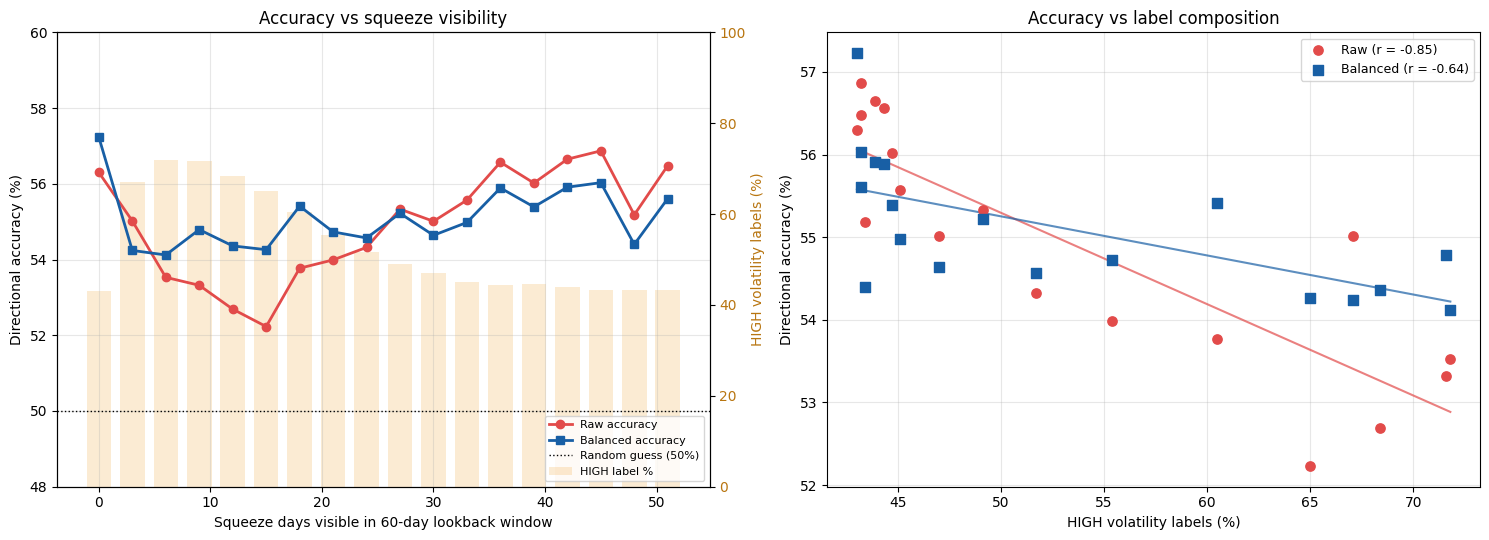

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- your final 18-point data ---
cont = [0,3,6,9,12,15,18,21,24,27,30,33,36,39,42,45,48,51]
raw  = [56.30,55.02,53.53,53.32,52.69,52.23,53.77,53.99,54.32,55.33,
        55.01,55.57,56.57,56.02,56.65,56.87,55.18,56.48]
bal  = [57.23,54.24,54.12,54.79,54.36,54.26,55.41,54.73,54.57,55.22,
        54.64,54.98,55.89,55.39,55.91,56.03,54.40,55.61]
high = [43.0,67.1,71.8,71.6,68.4,65.0,60.5,55.4,51.7,49.1,
        47.0,45.1,44.3,44.7,43.9,43.2,43.4,43.2]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ---------- LEFT: accuracy vs contamination, HIGH% behind ----------
ax = axes[0]; ax2 = ax.twinx()
ax2.bar(cont, high, width=2.2, color='#EF9F27', alpha=0.20, zorder=1,
        label='HIGH label %')
ax2.set_ylabel('HIGH volatility labels (%)', color='#B87510')
ax2.tick_params(axis='y', labelcolor='#B87510'); ax2.set_ylim(0, 100)

ax.plot(cont, raw, 'o-', color='#E24B4A', linewidth=2, markersize=6,
        label='Raw accuracy', zorder=3)
ax.plot(cont, bal, 's-', color='#185FA5', linewidth=2, markersize=6,
        label='Balanced accuracy', zorder=3)
ax.axhline(50, color='black', linestyle=':', linewidth=1, zorder=2,
           label='Random guess (50%)')
ax.set_xlabel('Squeeze days visible in 60-day lookback window')
ax.set_ylabel('Directional accuracy (%)'); ax.set_ylim(48, 60)
ax.set_title('Accuracy vs squeeze visibility')
ax.set_zorder(ax2.get_zorder()+1); ax.patch.set_visible(False)
l1,lab1 = ax.get_legend_handles_labels()
l2,lab2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lab1+lab2, fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

# ---------- RIGHT: accuracy vs HIGH% scatter (the confound) ----------
ax = axes[1]
ax.scatter(high, raw, color='#E24B4A', s=45, label='Raw (r = -0.85)', zorder=3)
ax.scatter(high, bal, color='#185FA5', s=45, marker='s',
           label='Balanced (r = -0.64)', zorder=3)
for y, c in [(raw,'#E24B4A'), (bal,'#185FA5')]:
    m,b = np.polyfit(high, y, 1)
    xs = np.array([min(high), max(high)])
    ax.plot(xs, m*xs+b, color=c, linewidth=1.5, alpha=0.7, zorder=2)
ax.set_xlabel('HIGH volatility labels (%)')
ax.set_ylabel('Directional accuracy (%)')
ax.set_title('Accuracy vs label composition')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/lookback_contamination_test.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [22]:
import numpy as np, os
from sklearn.metrics import balanced_accuracy_score

DATA = "../data/simulated"   # where mc_returns_*.npy live
scenarios_files = {
    'Normal':             'mc_returns_normal.npy',
    '2008 Crisis':        'mc_returns_crisis_2008.npy',
    'COVID Crisis':       'mc_returns_crisis_covid.npy',
    'Synthetic Extreme':  'mc_returns_synthetic_extreme.npy',
    'Non-linear Squeeze': 'mc_returns_squeeze.npy',
    'Structural Break':   'mc_returns_structural_break.npy',
}

def labels_and_probs(paths):
    # same leak-free geometry as training
    feats  = paths[:, -(lookback+1):-1]                     # exclude target day
    recent = np.abs(paths[:, -(vol_window+1):-1]).mean(axis=1)
    labels = (np.abs(paths[:, -1]) > recent).astype(int)
    probs  = model.predict(scaler.transform(feats).reshape(-1, lookback, 1),
                           verbose=0).flatten()
    return probs, labels

scenario_data = {}
for name, fname in scenarios_files.items():
    paths = np.load(os.path.join(DATA, fname))
    probs, labels = labels_and_probs(paths)
    scenario_data[name] = {'probs': probs, 'labels': labels}
    print(f"{name:20} loaded {paths.shape[0]} paths, HIGH%={labels.mean()*100:.1f}")

Normal               loaded 10000 paths, HIGH%=43.2
2008 Crisis          loaded 10000 paths, HIGH%=42.5
COVID Crisis         loaded 10000 paths, HIGH%=42.7
Synthetic Extreme    loaded 10000 paths, HIGH%=42.9
Non-linear Squeeze   loaded 10000 paths, HIGH%=43.2
Structural Break     loaded 10000 paths, HIGH%=42.8


In [41]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import balanced_accuracy_score


def cohens_h(p1, p2):
    return abs(2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2)))

base_preds   = (scenario_data['Normal']['probs'] > 0.5).astype(int)
base_correct = (base_preds == scenario_data['Normal']['labels'])
base_acc     = base_correct.mean()

rows = []
print(f"{'Scenario':<20}{'raw%':>7}{'bal%':>7}{'HIGH%':>7}{'Δpp':>7}"
      f"{'z':>8}{'p':>9}{'sig':>5}{'h':>8}{'effect':>12}")
print("-"*95)
for name, d in scenario_data.items():
    preds   = (d['probs'] > 0.5).astype(int)
    correct = (preds == d['labels'])
    raw     = correct.mean()*100
    bal     = balanced_accuracy_score(d['labels'], preds)*100
    high    = d['labels'].mean()*100

    if name == 'Normal':
        print(f"{name:<20}{raw:>7.2f}{bal:>7.2f}{high:>7.1f}{'—':>7}"
              f"{'—':>8}{'—':>9}{'—':>5}{'—':>8}{'baseline':>12}")
        rows.append([name, f"{raw:.2f}", f"{bal:.2f}", f"{high:.1f}",
                     "—","—","—","—","baseline"])
        continue

    delta   = (raw/100 - base_acc)*100
    stat, p = proportions_ztest(
        count=[correct.sum(), base_correct.sum()],
        nobs=[len(correct), len(base_correct)],
        alternative='two-sided')
    h   = cohens_h(base_acc, raw/100)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    eff = 'negligible' if h<0.2 else 'small' if h<0.5 else 'medium'

    print(f"{name:<20}{raw:>7.2f}{bal:>7.2f}{high:>7.1f}{delta:>+7.2f}"
          f"{stat:>8.3f}{p:>9.4f}{sig:>5}{h:>8.4f}{eff:>12}")
    rows.append([name, f"{raw:.2f}", f"{bal:.2f}", f"{high:.1f}",
                 f"{delta:+.2f}", f"{stat:.3f}", f"{p:.4f}", sig, eff])

print("\nBonferroni threshold for 5 comparisons: α = 0.01")
pd.DataFrame(rows, columns=['Scenario','Raw%','Bal%','HIGH%','Δpp','z',
                            'p','Sig','Effect']).to_csv(
    '../results/ztest_significance_results.csv', index=False)
print("Saved to ../results/ztest_significance_results.csv")

Scenario               raw%   bal%  HIGH%    Δpp       z        p  sig       h      effect
-----------------------------------------------------------------------------------------------
Normal                55.37  56.38   43.2      —       —        —    —       —    baseline
2008 Crisis           56.43  56.88   42.5  +1.06   1.510   0.1311   ns  0.0213  negligible
COVID Crisis          56.85  57.58   42.7  +1.48   2.109   0.0350    *  0.0298  negligible
Synthetic Extreme     56.48  56.79   42.9  +1.11   1.581   0.1139   ns  0.0224  negligible
Non-linear Squeeze    56.48  55.61   43.2  +1.11   1.581   0.1139   ns  0.0224  negligible
Structural Break      56.30  56.62   42.8  +0.93   1.324   0.1854   ns  0.0187  negligible

Bonferroni threshold for 5 comparisons: α = 0.01
Saved to ../results/ztest_significance_results.csv


In [23]:
# --- Path-level bootstrap on the DIFFERENCE r_raw - r_bal ---
# Requires storing per-path correctness AND labels at each contamination level.
# Restructure: for each cont level, keep the full per-path label & pred arrays.

cont_labels, cont_preds = {}, {}
for cont in contamination_days:
    end_idx, start_idx = SQUEEZE_ONSET + cont, SQUEEZE_ONSET + cont - lookback
    if start_idx < 0 or end_idx >= PATH_LENGTH:
        continue
    feats  = squeeze_paths[:, start_idx:end_idx]
    recent = np.abs(squeeze_paths[:, end_idx-vol_window:end_idx]).mean(axis=1)
    cont_labels[cont] = (np.abs(squeeze_paths[:, end_idx]) > recent).astype(int)
    probs = model.predict(scaler.transform(feats).reshape(-1, lookback, 1), verbose=0).flatten()
    cont_preds[cont]  = (probs > 0.5).astype(int)

cs = sorted(cont_labels)
N  = squeeze_paths.shape[0]
rng = np.random.default_rng(42)
B = 2000
diffs = np.empty(B)

for b in range(B):
    idx = rng.integers(0, N, size=N)              # resample PATHS with replacement
    high, raw, bal = [], [], []
    for c in cs:
        lab, prd = cont_labels[c][idx], cont_preds[c][idx]
        high.append(lab.mean())
        raw.append((prd == lab).mean())
        bal.append(balanced_accuracy_score(lab, prd))
    rr = np.corrcoef(high, raw)[0,1]
    rb = np.corrcoef(high, bal)[0,1]
    diffs[b] = rr - rb                             # the estimand that matters

lo_ci, hi_ci = np.percentile(diffs, [2.5, 97.5])
print(f"\nBootstrap r_raw - r_bal: mean={diffs.mean():.3f}, "
      f"95% CI [{lo_ci:.3f}, {hi_ci:.3f}]")
print("Difference is significant." if hi_ci < 0 else "CI includes 0 — difference NOT significant.")code is not showing any result

SyntaxError: invalid syntax (1455884513.py, line 37)

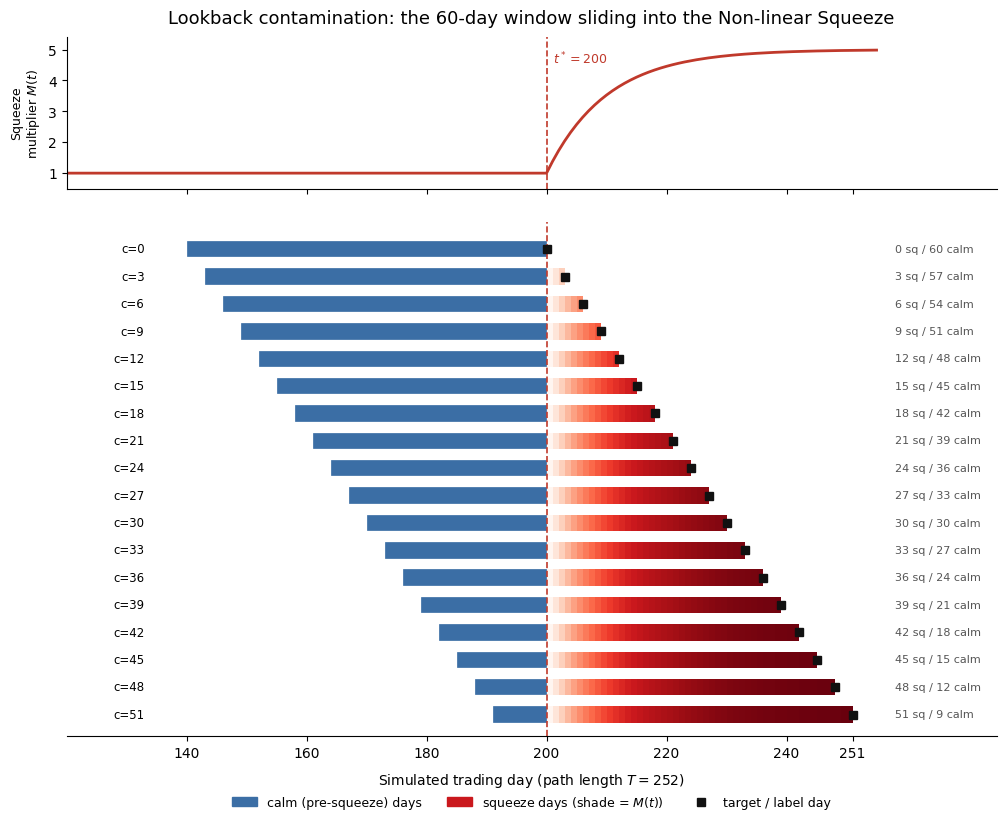

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines
from matplotlib import colors, colormaps

# ---- protocol parameters (match your thesis) ----
t_star = 200        # squeeze onset day (t*)
L      = 60         # feature-window length
M_max  = 5.0        # asymptotic squeeze multiplier
tau    = 10.0       # squeeze time constant
cs     = list(range(0, 52, 3))   # 18 contamination levels: 0,3,...,51

# ---- Non-linear Squeeze multiplier M(t) ----
def M(t):
    t = np.asarray(t, dtype=float)
    return np.where(t < t_star, 1.0,
                    1 + (M_max - 1) * (1 - np.exp(-(t - t_star) / tau)))

# ---- figure: top panel = M(t), bottom panel = sliding windows ----
fig, (ax_top, ax) = plt.subplots(
    2, 1, figsize=(12, 9.2), sharex=True,
    gridspec_kw={"height_ratios": [1, 3.4], "hspace": 0.10})

# top: the exponential squeeze multiplier
days = np.arange(120, 256)
ax_top.plot(days, M(days), color="#c0392b", lw=2)
ax_top.axvline(t_star, color="#c0392b", ls="--", lw=1.2)
ax_top.text(t_star + 1, 5.0, r"$t^*=200$", color="#c0392b", fontsize=9, va="top")
ax_top.set_ylabel("Squeeze\nmultiplier $M(t)$", fontsize=9)
ax_top.set_ylim(0.5, 5.4)
ax_top.set_title("Lookback contamination: the 60-day window sliding into the "
                 "Non-linear Squeeze", fontsize=13, pad=10)
for s in ["top", "right"]:
    ax_top.spines[s].set_visible(False)

# bottom: one horizontal bar per contamination level
norm = colors.Normalize(vmin=1.0, vmax=M_max)
reds = colormaps["Reds"]
pre_col, tgt_col = "#3b6ea5", "#111111"

for i, c in enumerate(cs):
    y        = len(cs) - i          # c=0 at top
    t_start  = t_star + c - L       # window start = 140 + c
    win_last = t_star + c - 1       # last day inside the window = 199 + c
    t_end    = t_star + c           # target/label day (excluded) = 200 + c

    # calm (pre-squeeze) portion
    pre_end = min(win_last, t_star - 1)
    if pre_end >= t_start:
        ax.barh(y, pre_end - t_start + 1, left=t_start, height=0.6,
                color=pre_col, edgecolor="white", linewidth=0.2)

    # squeeze portion, each day shaded by its multiplier M(t)
    for d in range(max(t_start, t_star), win_last + 1):
        ax.barh(y, 1, left=d, height=0.6,
                color=reds(norm(float(M(d)))), edgecolor="none")

    # target/label day marker
    ax.plot(t_end, y, marker="s", color=tgt_col, markersize=5.5, zorder=5)

    # row labels
    ax.text(133, y, f"c={c}", va="center", ha="right", fontsize=8.5)
    ax.text(258, y, f"{c} sq / {L - c} calm", va="center", ha="left",
            fontsize=8, color="#555")

ax.axvline(t_star, color="#c0392b", ls="--", lw=1.2)
ax.set_xlim(120, 275)
ax.set_ylim(0.2, len(cs) + 1.0)
ax.set_yticks([])
ax.set_xlabel("Simulated trading day (path length $T = 252$)", labelpad=8)
ax.set_xticks([140, 160, 180, 200, 220, 240, 251])
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)

handles = [
    Patch(color=pre_col, label="calm (pre-squeeze) days"),
    Patch(color=reds(0.75), label="squeeze days (shade = $M(t)$)"),
    mlines.Line2D([], [], color=tgt_col, marker="s", linestyle="None",
                  markersize=6, label="target / label day"),
]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.09),
          ncol=3, frameon=False, fontsize=9)

plt.subplots_adjust(bottom=0.12)
plt.savefig("contamination_windows.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
plt.savefig('../results/contamination_windows.png', dpi=150, bbox_inches='tight')
print("Saved to ../results/contamination_windows.png")

Saved to ../results/contamination_windows.png


<Figure size 640x480 with 0 Axes>

In [24]:
import pandas as pd

t_star, L = 200, 60
rows = []
for c in range(0, 52, 3):
    rows.append({
        "c": c,
        "window_start": t_star + c - L,     # 140 + c
        "window_end":   t_star + c - 1,     # 199 + c  (last day in window)
        "target_day":   t_star + c,         # 200 + c  (label day, excluded)
        "squeeze_days": c,
        "calm_days":    L - c,
    })

contamination_windows = pd.DataFrame(rows)
contamination_windows.to_csv('../results/contamination_windows.csv', index=False)
print("Saved to ../results/contamination_windows.csv")

Saved to ../results/contamination_windows.csv
